# Principal Component Analysis (PCA)

## The Core Problem

We want to encode high-dimensional data $X \in \mathbb{R}^{m \times n}$ (m samples, n features) into a lower-dimensional representation while minimizing reconstruction error.

The optimization problem is:
$$D^* = \arg\min_D \sum_{i,j} \left[ x^{(i)}_j - r(x^{(i)})_j \right]^2 \quad \text{subject to } D^T D = I_l$$

Where:
- $D$ is the encoding matrix (decoder)  
- $r(x^{(i)}) = D d^T x^{(i)}$ is the reconstruction
- The constraint ensures $D$ has orthonormal columns

## Derivation for Single Component ($l=1$)

For a single principal component, $D$ becomes a vector $d$. The problem becomes:
$$d^* = \arg\min_d \|X - Xdd^T\|_F^2 \quad \text{subject to } \|d\|_2 = 1$$

Expanding the Frobenius norm:
$$\|X - Xdd^T\|_F^2 = \text{Tr}(X^T X) - 2\text{Tr}(X^T X dd^T) + \text{Tr}(d d^T X^T X d d^T)$$

With the constraint $d^T d = 1$, this simplifies to:
$$d^* = \arg\max_d \text{Tr}(d X^T X d) \quad \text{subject to } d^T d = 1$$

**Key insight**: The optimal $d$ is the **eigenvector of $X^T X$ corresponding to the largest eigenvalue**.

## Multiple Components

For $l > 1$, the optimal encoding matrix $D$ consists of the $l$ eigenvectors of $X^T X$ corresponding to the $l$ largest eigenvalues.

This means: **the principal components are ordered by how much variance they capture** (eigenvalues measure variance).

## Implementation Strategy

1. Center the data: $X_{\text{centered}} = X - \bar{X}$
2. Compute covariance: $C = \frac{1}{n-1} X_{\text{centered}}^T X_{\text{centered}}$
3. Find eigenvalues/eigenvectors of $C$
4. Sort by eigenvalues (descending)
5. Project onto top $k$ eigenvectors: $X_{\text{reduced}} = X_{\text{centered}} \cdot D_k$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

## Code Implementation

The `my_pca` function below implements the derivation above. Key steps:

- **Centering**: Subtract mean to ensure $\mathbb{E}[X_{\text{centered}}] = 0$
- **Covariance**: $(X^T X) / (n-1)$ is the sample covariance matrix (dividing by $n-1$ for unbiased estimate)
- **Eigendecomposition**: `np.linalg.eigh()` finds eigenvectors and eigenvalues
- **Selection**: Top $k$ eigenvectors are the principal components that explain the most variance
- **Projection**: Multiply centered data by the top eigenvectors to get reduced representation

In [6]:

def my_pca(X, n_components):
    # Calculate the mean of each column (axis=0 means compute across rows)
    X_mean = np.mean(X, axis=0)

    # Subtract the mean from our original data
    X_centered = X - X_mean

    print("Centered Data:\n", X_centered)

    # Get the number of samples (rows)
    n_samples = X_centered.shape[0]

    # Calculate the covariance matrix using matrix multiplication
    # Note: In Python, the '@' symbol performs matrix multiplication
    cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

    print("\nCovariance Matrix:\n", cov_matrix)

    # find eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    print("\nEigenvalues:\n", eigenvalues)
    print("\nEigenvectors:\n", eigenvectors)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    print("\nSorted Indices:\n", sorted_indices)

    # Sort eigenvalues and eigenvectors
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    print("\nSorted Eigenvalues:\n", eigenvalues)
    print("\nSorted Eigenvectors:\n", eigenvectors)

    # Choose how many dimensions we want to keep
    k = n_components 

    # Slice the eigenvector matrix to keep only the top 'k' columns
    # eigenvectors[:, 0:1] gives us all rows, but only the first column
    top_eigenvectors = eigenvectors[:, 0:k]

    # Project the data using matrix multiplication
    X_reduced = X_centered @ top_eigenvectors

    print("Original 2D Data Shape:", X_centered.shape)
    print("Reduced 1D Data Shape:", X_reduced.shape)
    print("\nFinal Compressed Data:\n", X_reduced)

    return X_reduced

Centered Data:
 [[ 0.         -0.30383973 -0.20478575 ... -6.7640512  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973 -5.20478575 ...  3.2359488  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973 -5.20478575 ...  9.2359488   6.93210907
  -0.36449638]
 ...
 [ 0.         -0.30383973 -4.20478575 ... -0.7640512  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973 -3.20478575 ...  5.2359488  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973  4.79521425 ...  5.2359488  -1.06789093
  -0.36449638]]

Covariance Matrix:
 [[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.8229975   2.40099498 ... -0.1598953   0.09851423
  -0.07406182]
 [ 0.          2.40099498 22.60837352 ... -1.15544033  1.41203571
   0.72988047]
 ...
 [ 0.         -0.1598953  -1.15544033 ... 34.81734839 15.64854441
   2.87558266]
 [ 0.          0.09851423  1.41203571 ... 15.64854441 16.73258202
   4.72078588]
 [ 0.         -0.07406182  0.72988047 ...  2.87558266  4.72078588
   

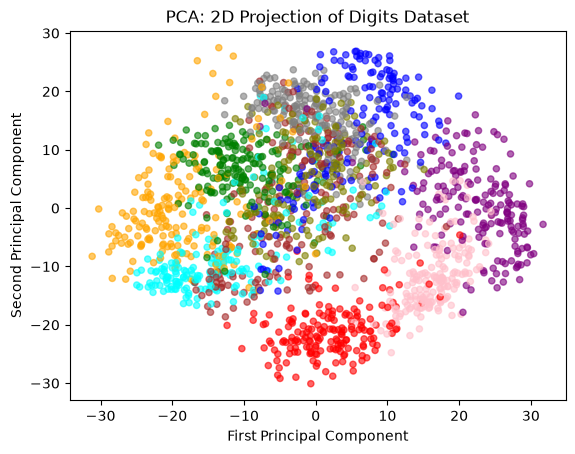

In [7]:
if __name__ == "__main__":
    digits = load_digits()
    X = digits.data
    X_reduced = my_pca(X, 2)
    
    # Plot the reduced data colored by true labels with clear visualization
    label_to_color = {
        0: 'red',
        1: 'blue',
        2: 'green',
        3: 'orange',
        4: 'purple',
        5: 'brown',
        6: 'pink',
        7: 'gray',
        8: 'olive',
        9: 'cyan'
    }
    colors = [label_to_color[label] for label in digits.target]
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=colors, alpha=0.6, s=20)
    plt.title('PCA: 2D Projection of Digits Dataset')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.show()


## Visualization Insights

The plot above shows 2D PCA projection of the 64-dimensional digits dataset (8×8 pixel images).

- **Each dot** is a handwritten digit, reduced from 64 dimensions to 2
- **Colors** represent the true labels (0-9)
- **Axes** are the first two principal components (capturing ~25-30% of total variance)

Notice that digits with similar shapes (e.g., 0 and 6, 3 and 8) cluster closer together, even though we've discarded ~96% of the original features. This is the power of PCA: the principal components capture the directions of maximum variance—which often correspond to meaningful structure in the data.